In [1]:
!nvidia-smi

Thu Oct  8 07:04:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from numba import cuda
import numpy as np
import time
import math
import hashlib

assert cuda.is_available(), "GPU is unavailable: check the T4 connection."

device = cuda.get_current_device()
device_name = device.name
if isinstance(device_name, bytes):
    device_name = device_name.decode("utf-8")

print("Device Name:", device_name)
print("Compute Capability:", device.compute_capability)
print("Multiprocessor Count (SMs):",
      getattr(device, "MULTIPROCESSOR_COUNT", "N/A"))
print("Max Threads Per Block:", device.MAX_THREADS_PER_BLOCK)
print("Max Block Dimensions:",
      device.MAX_BLOCK_DIM_X,
      device.MAX_BLOCK_DIM_Y,
      device.MAX_BLOCK_DIM_Z)
print("Warp Size:", device.WARP_SIZE)

Device Name: Tesla T4
Compute Capability: ComputeCapability(major=7, minor=5)
Multiprocessor Count (SMs): 40
Max Threads Per Block: 1024
Max Block Dimensions: 1024 1024 64
Warp Size: 32


In [3]:
STUDENT_ID = "230103014"
STUDENT_SEED = int(STUDENT_ID)

print("Student ID:", STUDENT_ID)
print("Random seed:", STUDENT_SEED)

Student ID: 230103014
Random seed: 230103014


In [4]:
def double_cpu_pure(arr):
    out = np.empty_like(arr)
    for i in range(len(arr)):
        out[i] = arr[i] * 2.0
    return out


@cuda.jit
def double_gpu_kernel(d_in, d_out):
    idx = cuda.grid(1)
    if idx < d_in.shape[0]:
        d_out[idx] = d_in[idx] * 2.0


def benchmark_run(N, student_id_seed):
    np.random.seed(student_id_seed)
    h_in = np.random.rand(N).astype(np.float32)

    # Measure the CPU loop for arrays up to one million elements.
    if N <= 1_000_000:
        t0 = time.perf_counter()
        cpu_out = double_cpu_pure(h_in)
        cpu_time_ms = (time.perf_counter() - t0) * 1000.0
    else:
        cpu_out = None
        cpu_time_ms = float("nan")

    threads_per_block = 256
    blocks_per_grid = (N + threads_per_block - 1) // threads_per_block

    # Compile and warm up the kernel before timing.
    d_warmup = cuda.to_device(np.ones(10, dtype=np.float32))
    double_gpu_kernel[1, 32](d_warmup, d_warmup)
    cuda.synchronize()

    # Measure transfers, allocation, kernel execution, and synchronization.
    t0 = time.perf_counter()
    d_in = cuda.to_device(h_in)
    d_out = cuda.device_array_like(d_in)
    double_gpu_kernel[blocks_per_grid, threads_per_block](d_in, d_out)
    h_out = d_out.copy_to_host()
    cuda.synchronize()
    gpu_total_ms = (time.perf_counter() - t0) * 1000.0

    # Measure kernel launch and completion without data transfers.
    t0 = time.perf_counter()
    double_gpu_kernel[blocks_per_grid, threads_per_block](d_in, d_out)
    cuda.synchronize()
    gpu_compute_ms = (time.perf_counter() - t0) * 1000.0

    # Validate results outside the timed sections.
    np.testing.assert_allclose(h_out, h_in * 2.0)
    if cpu_out is not None:
        np.testing.assert_allclose(h_out, cpu_out)

    return cpu_time_ms, gpu_total_ms, gpu_compute_ms

In [5]:
sizes = [
    100,
    1_000,
    10_000,
    100_000,
    1_000_000,
    5_000_000,
    10_000_000
]

benchmark_results = []

print(
    f"{'N':>10} | {'CPU ms':>12} | {'GPU Total ms':>14} | "
    f"{'GPU Kernel ms':>14} | Winner"
)
print("-" * 85)

for N in sizes:
    cpu_ms, total_ms, kernel_ms = benchmark_run(N, STUDENT_SEED)

    if np.isnan(cpu_ms):
        cpu_text = "SKIPPED"
        winner = "Not measured"
    else:
        cpu_text = f"{cpu_ms:.6f}"
        if total_ms < cpu_ms:
            winner = "GPU"
        elif cpu_ms < total_ms:
            winner = "CPU"
        else:
            winner = "TIE"

    benchmark_results.append({
        "N": N,
        "cpu_ms": cpu_ms,
        "gpu_total_ms": total_ms,
        "gpu_kernel_ms": kernel_ms,
        "winner": winner
    })

    print(
        f"{N:>10} | {cpu_text:>12} | {total_ms:>14.6f} | "
        f"{kernel_ms:>14.6f} | {winner}"
    )

gpu_wins = [
    row["N"]
    for row in benchmark_results
    if not np.isnan(row["cpu_ms"])
    and row["gpu_total_ms"] < row["cpu_ms"]
]

CROSSOVER_N = min(gpu_wins) if gpu_wins else None

print("\nFirst measured GPU win, N*:", CROSSOVER_N)

small = benchmark_results[0]
extra_ms = small["gpu_total_ms"] - small["gpu_kernel_ms"]
extra_percent = 100.0 * extra_ms / small["gpu_total_ms"]

print(f"For N=100, Total minus Kernel: {extra_ms:.6f} ms")
print(f"Approximate share of extra time: {extra_percent:.2f}%")
print("\nAll output validation checks passed.")

         N |       CPU ms |   GPU Total ms |  GPU Kernel ms | Winner
-------------------------------------------------------------------------------------


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 40 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


       100 |     0.066760 |       1.377020 |       0.081868 | CPU
      1000 |     0.436177 |       0.960317 |       0.095273 | CPU
     10000 |     4.429640 |       0.860660 |       0.119416 | GPU
    100000 |    38.678029 |       1.023637 |       0.108874 | GPU
   1000000 |   257.259945 |       4.716472 |       0.121303 | GPU
   5000000 |      SKIPPED |      13.650887 |       0.255350 | Not measured
  10000000 |      SKIPPED |      23.713584 |       0.440629 | Not measured

First measured GPU win, N*: 10000
For N=100, Total minus Kernel: 1.295152 ms
Approximate share of extra time: 94.05%

All output validation checks passed.


In [6]:
import subprocess
import sys

defective_script = r'''
from numba import cuda
import numpy as np

@cuda.jit
def defective_kernel(d_arr):
    idx = cuda.grid(1)
    # Intentionally missing the bounds check.
    d_arr[idx] = 999.0

N = 1000
h_arr = np.zeros(N, dtype=np.float32)
d_arr = cuda.to_device(h_arr)

threads_per_block = 256
blocks_per_grid = 4

print(
    "Launching defective kernel with 1024 threads "
    "on a 1000-element array...",
    flush=True
)

defective_kernel[blocks_per_grid, threads_per_block](d_arr)
cuda.synchronize()

print(
    "Execution finished (or did it crash?). Checking host copy...",
    flush=True
)

h_result = d_arr.copy_to_host()
print(
    f"Elements processed: {len(h_result)}. "
    f"Last element: {h_result[-1]}",
    flush=True
)
'''

run = subprocess.run(
    [sys.executable, "-u", "-c", defective_script],
    capture_output=True,
    text=True
)

print("STDOUT:")
print(run.stdout or "(empty)")

print("\nSTDERR:")
print(run.stderr or "(empty)")

print("\nProcess return code:", run.returncode)

STDOUT:
Launching defective kernel with 1024 threads on a 1000-element array...
Execution finished (or did it crash?). Checking host copy...
Elements processed: 1000. Last element: 999.0


STDERR:
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Process return code: 0


In [7]:
@cuda.jit
def inspect_threads_kernel(log_block, log_thread, log_global, log_active, N):
    t_idx = cuda.threadIdx.x
    b_idx = cuda.blockIdx.x
    g_idx = cuda.grid(1)

    # The log arrays include all launched threads.
    if g_idx < log_block.shape[0]:
        log_block[g_idx] = b_idx
        log_thread[g_idx] = t_idx
        log_global[g_idx] = g_idx
        log_active[g_idx] = 1 if g_idx < N else 0


N = 37
threads_per_block = 8
blocks_per_grid = (N + threads_per_block - 1) // threads_per_block
total_threads = blocks_per_grid * threads_per_block

log_b = cuda.device_array(total_threads, dtype=np.int32)
log_t = cuda.device_array(total_threads, dtype=np.int32)
log_g = cuda.device_array(total_threads, dtype=np.int32)
log_a = cuda.device_array(total_threads, dtype=np.int32)

inspect_threads_kernel[blocks_per_grid, threads_per_block](
    log_b, log_t, log_g, log_a, N
)
cuda.synchronize()

host_b = log_b.copy_to_host()
host_t = log_t.copy_to_host()
host_g = log_g.copy_to_host()
host_a = log_a.copy_to_host()

print(
    f"{'Global ID':<10} | {'Block ID':<10} | "
    f"{'Thread ID':<10} | Status"
)
print("-" * 65)

for i in range(32, 40):
    status = "ACTIVE" if host_a[i] == 1 else "IDLE (GUARDED)"
    print(
        f"{host_g[i]:<10} | {host_b[i]:<10} | "
        f"{host_t[i]:<10} | {status}"
    )

print("\nTotal Blocks Allocated:", blocks_per_grid)
print("Total Hardware Threads Launched:", total_threads)
print("Active Working Threads:", int(host_a.sum()))
print("Idle Guarded Threads:", int((host_a == 0).sum()))

Global ID  | Block ID   | Thread ID  | Status
-----------------------------------------------------------------
32         | 4          | 0          | ACTIVE
33         | 4          | 1          | ACTIVE
34         | 4          | 2          | ACTIVE
35         | 4          | 3          | ACTIVE
36         | 4          | 4          | ACTIVE
37         | 4          | 5          | IDLE (GUARDED)
38         | 4          | 6          | IDLE (GUARDED)
39         | 4          | 7          | IDLE (GUARDED)

Total Blocks Allocated: 5
Total Hardware Threads Launched: 40
Active Working Threads: 37
Idle Guarded Threads: 3


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 5 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [8]:
@cuda.jit
def naive_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)
    if idx < d_arr.shape[0]:
        # Unsynchronized updates to the same memory address.
        d_total[0] += d_arr[idx]


@cuda.jit
def atomic_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)
    if idx < d_arr.shape[0]:
        # Atomic addition prevents lost updates.
        cuda.atomic.add(d_total, 0, d_arr[idx])


N_SUM = 50_000
h_ones = np.ones(N_SUM, dtype=np.float32)
d_ones = cuda.to_device(h_ones)
d_total = cuda.to_device(np.zeros(1, dtype=np.float32))

sum_threads = 256
sum_blocks = (N_SUM + sum_threads - 1) // sum_threads
zero_total = np.zeros(1, dtype=np.float32)


def run_sum(kernel):
    # Reset the accumulator before every trial.
    d_total.copy_to_device(zero_total)
    cuda.synchronize()

    t0 = time.perf_counter()
    kernel[sum_blocks, sum_threads](d_ones, d_total)
    cuda.synchronize()
    elapsed_ms = (time.perf_counter() - t0) * 1000.0

    # Copy the result outside the timed section.
    value = float(d_total.copy_to_host()[0])
    return value, elapsed_ms


# Warm up both kernels to exclude compilation from timing.
run_sum(naive_sum_kernel)
run_sum(atomic_sum_kernel)

naive_results = []
naive_times = []

print("Trial | Target Sum | Naive Output | Lost Updates | Time ms")
print("-" * 65)

for trial in range(1, 6):
    value, elapsed_ms = run_sum(naive_sum_kernel)
    naive_results.append(value)
    naive_times.append(elapsed_ms)

    print(
        f"{trial} | {N_SUM:.1f} | {value:.1f} | "
        f"{N_SUM - value:.1f} | {elapsed_ms:.6f}"
    )

atomic_value, atomic_ms = run_sum(atomic_sum_kernel)
naive_ms = float(np.median(naive_times))

print("\nAtomic Sum Output:", atomic_value)
print("Equals exactly 50000.0:", atomic_value == 50_000.0)
print(f"Naive Kernel Time (median of 5 trials): {naive_ms:.6f} ms")
print(f"Atomic Kernel Time (1 measured trial): {atomic_ms:.6f} ms")

Trial | Target Sum | Naive Output | Lost Updates | Time ms
-----------------------------------------------------------------
1 | 50000.0 | 2.0 | 49998.0 | 0.932053
2 | 50000.0 | 2.0 | 49998.0 | 0.126128
3 | 50000.0 | 2.0 | 49998.0 | 0.115403
4 | 50000.0 | 2.0 | 49998.0 | 0.112547
5 | 50000.0 | 2.0 | 49998.0 | 0.110676

Atomic Sum Output: 50000.0
Equals exactly 50000.0: True
Naive Kernel Time (median of 5 trials): 0.115403 ms
Atomic Kernel Time (1 measured trial): 0.272819 ms


Generated 2D matrix shape: (1024, 1024)
Blocks in X: 64
Blocks in Y: 64
Total Blocks: 4096
Center pixel (512, 512): 1.0
Outer corner pixel (0, 0): 0.0


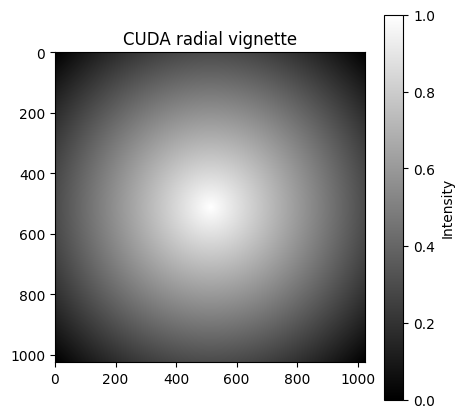

In [9]:
@cuda.jit
def radial_vignette_2d(d_canvas, width, height, center_x, center_y):
    x, y = cuda.grid(2)

    if x < width and y < height:
        dx = float(x - center_x)
        dy = float(y - center_y)

        dist = math.sqrt(dx * dx + dy * dy)
        max_dist = math.sqrt(float(center_x**2 + center_y**2))

        intensity = 1.0 - dist / max_dist
        if intensity < 0.0:
            intensity = 0.0

        d_canvas[y, x] = intensity


WIDTH, HEIGHT = 1024, 1024
canvas = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
d_canvas = cuda.to_device(canvas)

# Each block contains 16 x 16 = 256 threads.
threads_2d = (16, 16)
blocks_2d = (
    (WIDTH + threads_2d[0] - 1) // threads_2d[0],
    (HEIGHT + threads_2d[1] - 1) // threads_2d[1]
)

radial_vignette_2d[blocks_2d, threads_2d](
    d_canvas,
    WIDTH,
    HEIGHT,
    WIDTH // 2,
    HEIGHT // 2
)
cuda.synchronize()

result_canvas = d_canvas.copy_to_host()

print("Generated 2D matrix shape:", result_canvas.shape)
print("Blocks in X:", blocks_2d[0])
print("Blocks in Y:", blocks_2d[1])
print("Total Blocks:", blocks_2d[0] * blocks_2d[1])
print("Center pixel (512, 512):", float(result_canvas[512, 512]))
print("Outer corner pixel (0, 0):", float(result_canvas[0, 0]))

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.imshow(result_canvas, cmap="gray", vmin=0, vmax=1)
plt.title("CUDA radial vignette")
plt.colorbar(label="Intensity")
plt.show()

In [10]:
def generate_lab_checksum(student_id_str, d_canvas, exp_table_crossover):
    h = hashlib.sha256()
    h.update(student_id_str.strip().encode("utf-8"))

    gpu_name = cuda.get_current_device().name
    if isinstance(gpu_name, str):
        gpu_name = gpu_name.encode("utf-8")
    h.update(gpu_name)

    h.update(d_canvas.copy_to_host()[:10, :10].tobytes())
    h.update(str(exp_table_crossover).encode("utf-8"))

    digest = h.hexdigest()[:16].upper()

    print("=" * 60)
    print(f"OFFICIAL VERIFICATION CHECKSUM TOKEN: {digest}")
    print("=" * 60)

    return digest


assert STUDENT_ID == "230103014", "Unexpected Student ID."
assert CROSSOVER_N == 10000, "Unexpected measured crossover value."

print("Student ID:", STUDENT_ID)
print("Measured crossover N*:", CROSSOVER_N)

LAB_TOKEN = generate_lab_checksum(
    STUDENT_ID,
    d_canvas,
    CROSSOVER_N
)

Student ID: 230103014
Measured crossover N*: 10000
OFFICIAL VERIFICATION CHECKSUM TOKEN: 362C093E22BC73CE
